In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, TensorDataset,random_split

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/danibedmarromero/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/danibedmarromero/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/danibedmarromero/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Text pre processing

In [2]:
df = pd.read_csv("Data/train.csv")
df = df.dropna(subset=['text', 'class'])

stop_words = set(stopwords.words("catalan"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^\w\s]", '', text)
    tokens = word_tokenize(text, language='spanish') #no es català però kinda close 
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess)

w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=3, workers=4, epochs=20)

def get_doc_vector(tokens):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

df['doc_vec'] = df['tokens'].apply(get_doc_vector)

### EDA

In [15]:
import matplotlib.pyplot as plt

In [28]:
df

,id,text,class,year,tokens,doc_vec
0,0,Licitació de la concessió administrativa de l'...,0,2013,"[licitació, concessió, administrativa, lús, pr...","[0.8957967, -0.5781355, 0.64788926, -0.9722673..."
1,1,Notificació de l'acord de deixar sense efecte ...,17,2013,"[notificació, lacord, deixar, efecte, laprovac...","[0.15443332, -0.3803987, -0.7712445, -1.159716..."
2,2,Aprovació de l'expedient de dissolució i liqui...,17,2013,"[aprovació, lexpedient, dissolució, liquidació...","[-0.3928086, -0.8087312, 0.33051616, -0.217996..."
3,3,Aprovació inicial de la modificació puntual de...,16,2013,"[aprovació, inicial, modificació, puntual, uso...","[0.46146864, -0.5732319, -0.16528416, -0.67011..."
4,4,Aprovació definitiva de l'avanç del Pla de mil...,16,2013,"[aprovació, definitiva, lavanç, pla, millora, ...","[0.41914174, -0.6609495, -1.2927454, -0.132848..."
...,...,...,...,...,...,...
216969,216969,Aprovació definitiva de la modificació de les ...,2,2020,"[aprovació, definitiva, modificació, ordenance...","[-0.78895193, 0.39300928, 0.27810687, -0.42697..."
216970,216970,Aprovació definitiva de l'acord de modificació...,2,2020,"[aprovació, definitiva, lacord, modificació, o...","[-0.6280865, -0.1757714, -0.14926831, -0.63822..."
216971,216971,Aprovació de la modificació dels preus públics...,2,2020,"[aprovació, modificació, preus, públics, lany]","[-1.7758076, 1.8397684, -0.3731059, -0.2718508..."
216972,216972,Aprovació definitiva de les ordenances fiscals...,2,2020,"[aprovació, definitiva, ordenances, fiscals, l...","[-0.6836835, 0.25887036, 0.11924751, -0.316871..."


In [13]:
class_per_year = df[['class','year']]
class_counts = class_per_year.groupby(['year', 'class']).size().reset_index(name='count')
pivot_df = class_counts.pivot(index='year', columns='class', values='count').fillna(0)
pivot_df

class,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
year,,,,,,,,,,,,,,,,,,,,,
2013,4540.0,236.0,2094.0,1809.0,374.0,15.0,475.0,52.0,681.0,942.0,...,0.0,3299.0,328.0,6554.0,1160.0,612.0,3998.0,1242.0,2289.0,450.0
2014,6034.0,304.0,1708.0,1482.0,418.0,35.0,657.0,92.0,791.0,919.0,...,57.0,3594.0,341.0,6760.0,1604.0,718.0,4647.0,1285.0,2119.0,315.0
2015,5192.0,273.0,1547.0,1191.0,429.0,56.0,1014.0,95.0,866.0,2097.0,...,241.0,3469.0,369.0,3352.0,1492.0,585.0,2587.0,929.0,1488.0,447.0
2016,5714.0,183.0,1693.0,1456.0,485.0,77.0,1326.0,148.0,968.0,1402.0,...,69.0,3616.0,488.0,279.0,2130.0,500.0,1160.0,348.0,661.0,219.0
2017,7483.0,281.0,1767.0,1458.0,507.0,110.0,1804.0,125.0,987.0,1416.0,...,66.0,3748.0,525.0,148.0,2562.0,507.0,949.0,277.0,684.0,192.0
2018,5730.0,210.0,1543.0,1466.0,544.0,156.0,2155.0,181.0,1014.0,1319.0,...,1.0,4109.0,622.0,150.0,2735.0,555.0,1074.0,231.0,625.0,150.0
2019,2812.0,243.0,1324.0,1204.0,493.0,214.0,2242.0,165.0,1210.0,2570.0,...,220.0,3926.0,695.0,122.0,2489.0,502.0,942.0,242.0,440.0,182.0
2020,2115.0,204.0,1599.0,1364.0,335.0,177.0,1979.0,143.0,1124.0,1215.0,...,18.0,4216.0,892.0,55.0,3231.0,446.0,836.0,174.0,393.0,83.0


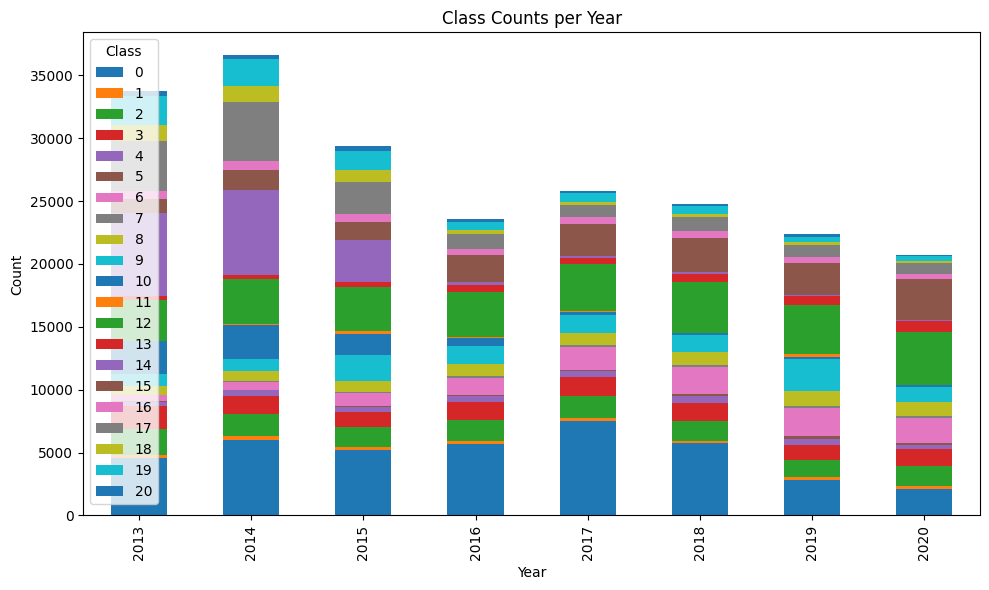

In [16]:
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Class Counts per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

### Train and test split

In [ ]:
df_test = df[df['year'].isin([2019, 2020])]
df_train_val = df[~df['year'].isin([2019, 2020])]

X_train_val = np.vstack(df_train_val['doc_vec'].values)
y_train_val = LabelEncoder().fit_transform(df_train_val['class'])
X_test = np.vstack(df_test['doc_vec'].values)
y_test = LabelEncoder().fit_transform(df_test['class'])

X_train_tensor = torch.tensor(X_train_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


### Model definition

In [5]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out)

model = TextClassifier(input_dim=100, hidden_dim=64, output_dim=21)
criterion = nn.CrossEntropyLoss()
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

/Users/danibedmarromero/Documents/Academia/MBD/Whale_classification/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/danibedmarromero/Documents/Academia/MBD/Whale_classification/.venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


### Model training

In [6]:
epoch = 0
trigger_times = 0
patience = 3
best_val_loss = float('inf')

epochs = []
total_losses = []
val_losses = []

while trigger_times < patience:
    
    model.train()
    epoch += 1

    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}, Learning Rate = {lr:.4f}")

    epochs.append(epoch)
    total_losses.append(total_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1: Train Loss = 1682.5102, Val Loss = 0.2346, Learning Rate = 0.0010
Epoch 2: Train Loss = 1151.3562, Val Loss = 0.2143, Learning Rate = 0.0010
Epoch 3: Train Loss = 1077.8381, Val Loss = 0.2065, Learning Rate = 0.0010
Epoch 4: Train Loss = 1037.2796, Val Loss = 0.2023, Learning Rate = 0.0010
Epoch 5: Train Loss = 1005.8544, Val Loss = 0.1983, Learning Rate = 0.0010
Epoch 6: Train Loss = 983.9280, Val Loss = 0.1994, Learning Rate = 0.0010
Epoch 7: Train Loss = 977.5051, Val Loss = 0.1972, Learning Rate = 0.0010
Epoch 8: Train Loss = 972.9987, Val Loss = 0.1968, Learning Rate = 0.0010
Epoch 9: Train Loss = 958.3431, Val Loss = 0.1958, Learning Rate = 0.0010
Epoch 10: Train Loss = 950.0157, Val Loss = 0.1982, Learning Rate = 0.0010
Epoch 11: Train Loss = 942.0804, Val Loss = 0.1960, Learning Rate = 0.0010
Epoch 12: Train Loss = 940.3576, Val Loss = 0.1946, Learning Rate = 0.0010
Epoch 13: Train Loss = 934.2868, Val Loss = 0.1949, Learning Rate = 0.0010
Epoch 14: Train Loss = 929.10

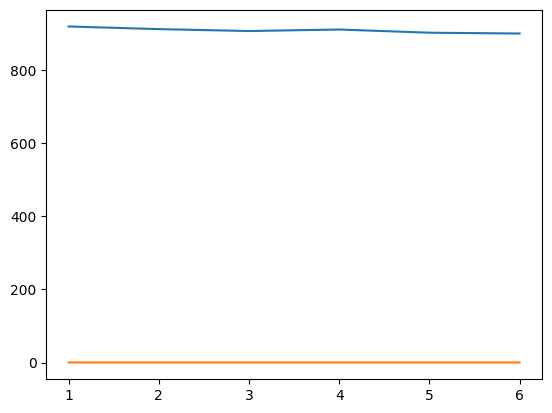

In [36]:
plt.plot(epochs, total_losses)
plt.plot(epochs, val_losses)

### Accuracy computation

In [7]:
# Final Evaluation on Test Set
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        _, predicted = torch.max(preds, 1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print(f"\nTest Accuracy: {correct / total:.4f}")


Test Accuracy: 0.9401
